Loading data...
Raw shapes: (1080, 28, 28, 3) (1080,) (400, 28, 28, 3)
Preprocessed shapes: (1080, 28, 28, 3) (400, 28, 28, 3)

--- Fold 1/5 (train 861 val 219) ---
Fold 1 ensemble val acc=0.4521 qwk=0.2151

--- Fold 2/5 (train 864 val 216) ---
Fold 2 ensemble val acc=0.3148 qwk=0.2031

--- Fold 3/5 (train 864 val 216) ---
Fold 3 ensemble val acc=0.2963 qwk=0.2642

--- Fold 4/5 (train 865 val 215) ---
Fold 4 ensemble val acc=0.4512 qwk=0.4361

--- Fold 5/5 (train 866 val 214) ---
Fold 5 ensemble val acc=0.5047 qwk=0.2994

OOF ensemble metrics:
OOF acc: 0.40370370370370373
OOF qwk: 0.2789189112378949
Saved: phase1_numpy_submission.csv

Classification Report (OOF predictions):
              precision    recall  f1-score   support

           0       0.66      0.58      0.61       486
           1       0.28      0.15      0.19       128
           2       0.30      0.07      0.12       206
           3       0.25      0.58      0.35       194
           4       0.10      0.14      0.11  

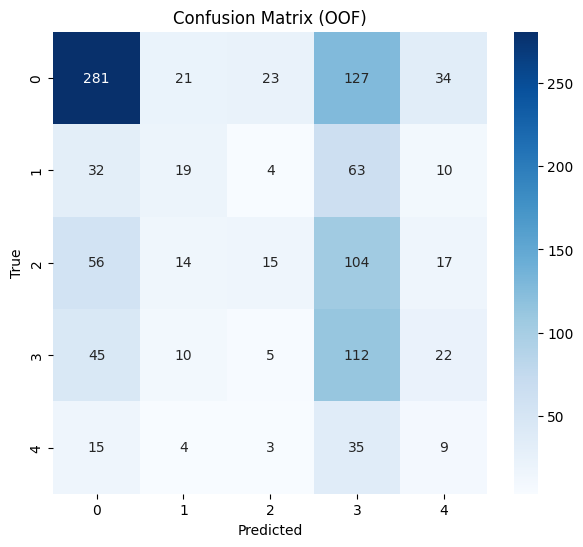

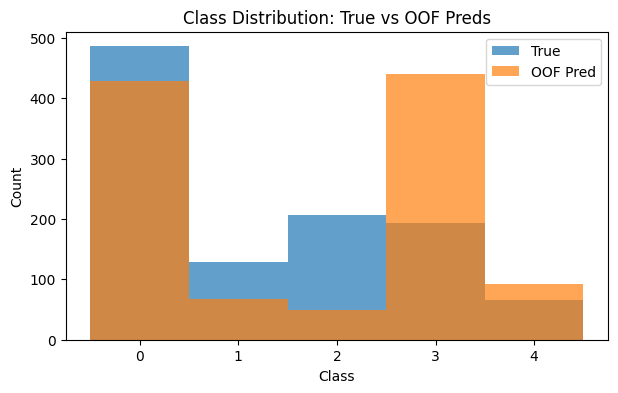

In [17]:

import pickle
import numpy as np
import csv
import sys
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
# Utilities: load data
# -------------------------
def load_pickle(path):
    with open(path, "rb") as f:
        return pickle.load(f)

def prepare_data(train_pkl, test_pkl, force_rgb=True):
    tr = load_pickle(train_pkl)
    te = load_pickle(test_pkl)

    X = np.array(tr["images"])
    y = np.array(tr["labels"])
    X_test = np.array(te["images"])

    if y.ndim > 1:
        y = y.reshape(-1)
    y = y.astype(int)

    if X.ndim == 3:
        X = X[..., None]
    if X_test.ndim == 3:
        X_test = X_test[..., None]

    if force_rgb:
        if X.shape[-1] == 1:
            X = np.concatenate([X, X, X], axis=-1)
        if X_test.shape[-1] == 1:
            X_test = np.concatenate([X_test, X_test, X_test], axis=-1)

    return X, y, X_test

# -------------------------
# Preprocessing
# -------------------------
def preprocess_images(X_train, X_test):
    X_train_f = X_train.astype(np.float32) / 255.0
    X_test_f = X_test.astype(np.float32) / 255.0

    mean = X_train_f.mean(axis=(0,1,2), keepdims=True)
    std  = X_train_f.std(axis=(0,1,2), keepdims=True) + 1e-6

    X_train_n = (X_train_f - mean) / std
    X_test_n  = (X_test_f  - mean) / std

    return X_train_n, X_test_n, mean, std

def flatten_images(X):
    return X.reshape((X.shape[0], -1))

# -------------------------
# Metrics
# -------------------------
def accuracy(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    return (y_true == y_pred).mean()

def quadratic_weighted_kappa(y_true, y_pred, min_rating=0, max_rating=4):
    y_true = np.asarray(y_true, dtype=int).reshape(-1)
    y_pred = np.asarray(y_pred, dtype=int).reshape(-1)
    assert y_true.shape == y_pred.shape
    N = len(y_true)
    num_ratings = max_rating - min_rating + 1
    O = np.zeros((num_ratings, num_ratings), dtype=float)
    for a,b in zip(y_true, y_pred):
        O[a-min_rating,b-min_rating] += 1
    hist_true = O.sum(axis=1)
    hist_pred = O.sum(axis=0)
    E = np.outer(hist_true, hist_pred) / N
    W = np.zeros((num_ratings, num_ratings), dtype=float)
    for i in range(num_ratings):
        for j in range(num_ratings):
            W[i,j] = ((i-j)**2) / ((num_ratings-1)**2)
    num = (W*O).sum()
    den = (W*E).sum()
    return 1.0 - num/den if den != 0 else 1.0

# -------------------------
# Helpers: softmax, one-hot
# -------------------------
def softmax(z):
    z = z - np.max(z, axis=1, keepdims=True)
    expz = np.exp(z)
    return expz / expz.sum(axis=1, keepdims=True)

def one_hot(y, n_classes):
    o = np.zeros((len(y), n_classes), dtype=np.float32)
    o[np.arange(len(y)), y] = 1.0
    return o

# -------------------------
# Stratified K-Fold (NumPy)
# -------------------------
def stratified_kfold_indices(y, n_splits=5, seed=42):
    y = np.asarray(y).reshape(-1)
    rng = np.random.RandomState(seed)
    classes, y_inv = np.unique(y, return_inverse=True)
    n_classes = len(classes)
    idxs = [np.where(y_inv == i)[0].tolist() for i in range(n_classes)]
    folds = [[] for _ in range(n_splits)]
    for i in range(n_classes):
        arr = idxs[i]
        rng.shuffle(arr)
        for j, ind in enumerate(arr):
            folds[j % n_splits].append(ind)
    splits = []
    for k in range(n_splits):
        val = np.array(folds[k], dtype=int)
        train = np.array([i for j in range(n_splits) if j != k for i in folds[j]], dtype=int)
        splits.append((train, val))
    return splits

# -------------------------
# Data augmentation (NumPy) - horizontal flip
# -------------------------
def augment_horizontal_flip(X, y):
    Xf = X[..., ::-1, :].copy()
    yf = y.copy()
    X_aug = np.concatenate([X, Xf], axis=0)
    y_aug = np.concatenate([y, yf], axis=0)
    return X_aug, y_aug

# -------------------------
# Model 1: Softmax Regression
# -------------------------
class SoftmaxRegression:
    def __init__(self, input_dim, n_classes, lr=1e-1, weight_decay=1e-4):
        self.W = np.zeros((input_dim, n_classes), dtype=np.float32)
        self.b = np.zeros((1, n_classes), dtype=np.float32)
        self.lr = lr
        self.weight_decay = weight_decay

    def predict_proba(self, X):
        logits = X.dot(self.W) + self.b
        return softmax(logits)

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)

    def fit(self, X, y, epochs=80, batch_size=128, verbose=False):
        N = X.shape[0]
        C = self.b.shape[1]
        Y = one_hot(y, C)
        for epoch in range(epochs):
            perm = np.random.permutation(N)
            for i in range(0, N, batch_size):
                idx = perm[i:i+batch_size]
                Xb = X[idx]
                Yb = Y[idx]
                probs = self.predict_proba(Xb)
                grad_logits = probs - Yb
                dW = (Xb.T @ grad_logits) / len(idx) + self.weight_decay * self.W
                db = grad_logits.mean(axis=0, keepdims=True)
                self.W -= self.lr * dW
                self.b -= self.lr * db
            if verbose and (epoch % 10 == 0 or epoch == epochs-1):
                preds = self.predict(X)
                print(f"[LR] epoch {epoch+1}/{epochs} acc={accuracy(y, preds):.4f}")

# -------------------------
# Model 2: Simple MLP
# -------------------------
class SimpleMLP:
    def __init__(self, input_dim, hidden_dim, n_classes, lr=1e-2, weight_decay=1e-4, seed=123):
        rng = np.random.RandomState(seed)
        self.W1 = rng.normal(scale=0.01, size=(input_dim, hidden_dim)).astype(np.float32)
        self.b1 = np.zeros((1, hidden_dim), dtype=np.float32)
        self.W2 = rng.normal(scale=0.01, size=(hidden_dim, n_classes)).astype(np.float32)
        self.b2 = np.zeros((1, n_classes), dtype=np.float32)
        self.lr = lr
        self.wd = weight_decay

    def forward(self, X):
        z1 = X.dot(self.W1) + self.b1
        a1 = np.maximum(0, z1)
        logits = a1.dot(self.W2) + self.b2
        return z1, a1, logits

    def predict_proba(self, X):
        _, a1, logits = self.forward(X)
        return softmax(logits)

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)

    def fit(self, X, y, epochs=100, batch_size=128, verbose=False):
        N = X.shape[0]
        C = np.max(y) + 1
        Y = one_hot(y, C)
        for epoch in range(epochs):
            perm = np.random.permutation(N)
            for i in range(0, N, batch_size):
                idx = perm[i:i+batch_size]
                Xb = X[idx]
                Yb = Y[idx]
                z1, a1, logits = self.forward(Xb)
                probs = softmax(logits)
                grad_logits = (probs - Yb) / max(1, len(idx))
                dW2 = a1.T.dot(grad_logits) + self.wd * self.W2
                db2 = grad_logits.sum(axis=0, keepdims=True)
                da1 = grad_logits.dot(self.W2.T)
                dz1 = da1 * (z1 > 0)
                dW1 = Xb.T.dot(dz1) + self.wd * self.W1
                db1 = dz1.sum(axis=0, keepdims=True)
                self.W2 -= self.lr * dW2
                self.b2 -= self.lr * db2
                self.W1 -= self.lr * dW1
                self.b1 -= self.lr * db1
            if verbose and (epoch % 10 == 0 or epoch == epochs-1):
                preds = self.predict(X)
                print(f"[MLP] epoch {epoch+1}/{epochs} acc={accuracy(y, preds):.4f}")

# -------------------------
# OOF training & ensemble
# -------------------------
def train_oof_and_ensemble(X_raw, y, X_test_raw, n_splits=5, seed=123):
    X = X_raw
    X_test = X_test_raw
    N = X.shape[0]
    Cnum = np.max(y) + 1

    splits = stratified_kfold_indices(y, n_splits=n_splits, seed=seed)

    oof_proba_lr = np.zeros((N, Cnum), dtype=float)
    oof_proba_mlp = np.zeros((N, Cnum), dtype=float)
    test_proba_lr = np.zeros((X_test.shape[0], Cnum), dtype=float)
    test_proba_mlp = np.zeros((X_test.shape[0], Cnum), dtype=float)

    for fold, (tr_idx, val_idx) in enumerate(splits):
        print(f"\n--- Fold {fold+1}/{n_splits} (train {len(tr_idx)} val {len(val_idx)}) ---")

        X_tr = X[tr_idx]
        y_tr = y[tr_idx]
        X_val = X[val_idx]
        y_val = y[val_idx]

        X_tr_aug, y_tr_aug = augment_horizontal_flip(X_tr, y_tr)

        X_tr_flat = flatten_images(X_tr_aug)
        X_val_flat = flatten_images(X_val)
        X_test_flat = flatten_images(X_test)

        input_dim = X_tr_flat.shape[1]

        lr_model = SoftmaxRegression(input_dim=input_dim, n_classes=Cnum, lr=0.2, weight_decay=1e-4)
        lr_model.fit(X_tr_flat, y_tr_aug, epochs=80, batch_size=128, verbose=False)
        proba_val_lr = lr_model.predict_proba(X_val_flat)
        oof_proba_lr[val_idx] = proba_val_lr
        proba_test_lr = lr_model.predict_proba(X_test_flat)
        test_proba_lr += proba_test_lr

        mlp_model = SimpleMLP(input_dim=input_dim, hidden_dim=512, n_classes=Cnum, lr=0.01, weight_decay=1e-4, seed=seed+fold)
        mlp_model.fit(X_tr_flat, y_tr_aug, epochs=80, batch_size=128, verbose=False)
        proba_val_mlp = mlp_model.predict_proba(X_val_flat)
        oof_proba_mlp[val_idx] = proba_val_mlp
        proba_test_mlp = mlp_model.predict_proba(X_test_flat)
        test_proba_mlp += proba_test_mlp

        preds_val_ens = np.argmax((proba_val_lr + proba_val_mlp)/2.0, axis=1)
        acc_val = accuracy(y_val, preds_val_ens)
        qwk_val = quadratic_weighted_kappa(y_val, preds_val_ens)
        print(f"Fold {fold+1} ensemble val acc={acc_val:.4f} qwk={qwk_val:.4f}")

    test_proba_lr /= n_splits
    test_proba_mlp /= n_splits

    oof_ens = np.argmax((oof_proba_lr + oof_proba_mlp)/2.0, axis=1)
    print("\nOOF ensemble metrics:")
    print("OOF acc:", accuracy(y, oof_ens))
    print("OOF qwk:", quadratic_weighted_kappa(y, oof_ens))

    test_proba_ens = (test_proba_lr + test_proba_mlp) / 2.0
    test_preds = np.argmax(test_proba_ens, axis=1)

    return test_preds, oof_ens, (oof_proba_lr, oof_proba_mlp)

# -------------------------
# Graphs and metrics plotting
# -------------------------
def plot_metrics(y_true, oof_preds):
    from sklearn.metrics import confusion_matrix, classification_report

    # Classification report
    print("\nClassification Report (OOF predictions):")
    print(classification_report(y_true, oof_preds))

    # Confusion matrix
    cm = confusion_matrix(y_true, oof_preds)
    plt.figure(figsize=(7,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title("Confusion Matrix (OOF)")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    # Class distribution
    plt.figure(figsize=(7,4))
    plt.hist(y_true, bins=np.arange(y_true.max()+2)-0.5, alpha=0.7, label="True")
    plt.hist(oof_preds, bins=np.arange(oof_preds.max()+2)-0.5, alpha=0.7, label="OOF Pred")
    plt.xticks(np.arange(y_true.max()+1))
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.legend()
    plt.title("Class Distribution: True vs OOF Preds")
    plt.show()

# -------------------------
# Main
# -------------------------
def main():
    print("Loading data...")
    X_raw, y, X_test_raw = prepare_data(
        "/kaggle/input/ift-3395-6390-kaggle-2-competition-fall-2025/train_data.pkl",
        "/kaggle/input/ift-3395-6390-kaggle-2-competition-fall-2025/test_data.pkl",
        force_rgb=True
    )
    print("Raw shapes:", X_raw.shape, y.shape, X_test_raw.shape)

    Xn, Xtestn, mean, std = preprocess_images(X_raw, X_test_raw)
    print("Preprocessed shapes:", Xn.shape, Xtestn.shape)

    test_preds, oof_preds, _ = train_oof_and_ensemble(Xn, y, Xtestn, n_splits=5, seed=42)

    # Save submission
    out_name = "phase1_numpy_submission.csv"
    with open(out_name, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["ID", "Label"])
        for i, p in enumerate(test_preds, start=1):
            writer.writerow([i, int(p)])
    print("Saved:", out_name)

    # Plot metrics
    plot_metrics(y, oof_preds)

    return X_raw, y, test_preds, oof_preds

if __name__ == "__main__":
    X_raw, y, test_preds, oof_preds = main()


OOF Accuracy: 0.40370370370370373
OOF QWK: 0.2789189112378949

Classification Report (OOF predictions):
              precision    recall  f1-score   support

           0     0.6550    0.5782    0.6142       486
           1     0.2794    0.1484    0.1939       128
           2     0.3000    0.0728    0.1172       206
           3     0.2540    0.5773    0.3528       194
           4     0.0978    0.1364    0.1139        66

    accuracy                         0.4037      1080
   macro avg     0.3172    0.3026    0.2784      1080
weighted avg     0.4367    0.4037    0.3921      1080



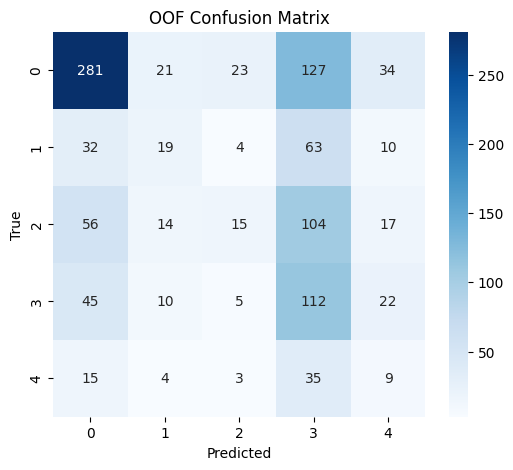

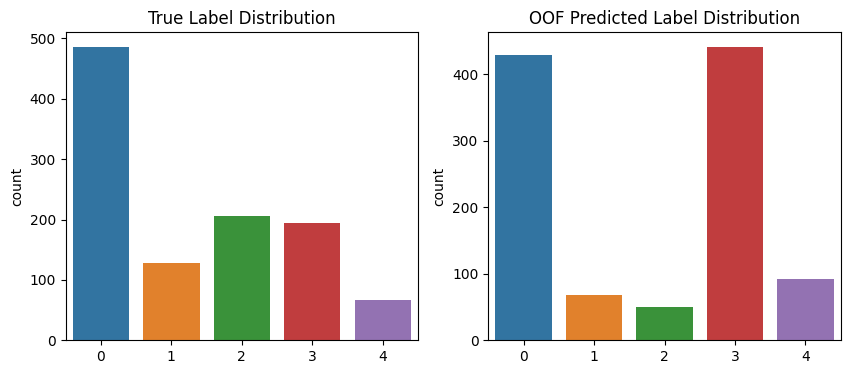

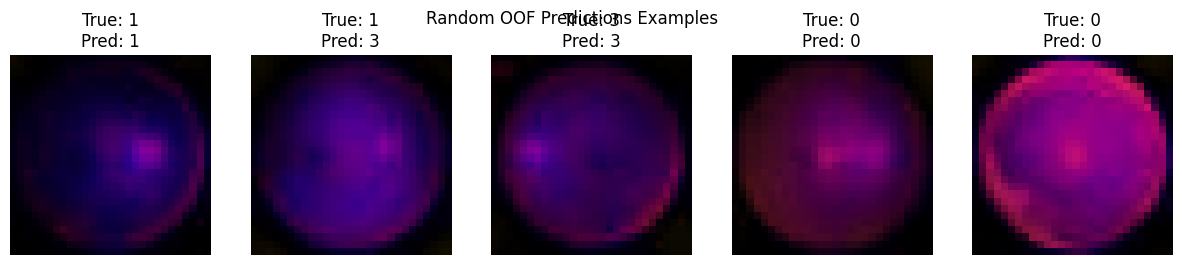

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# -------------------------
# 1️⃣ Overall OOF metrics
# -------------------------
print("OOF Accuracy:", accuracy(y, oof_preds))
print("OOF QWK:", quadratic_weighted_kappa(y, oof_preds))
print("\nClassification Report (OOF predictions):")
print(classification_report(y, oof_preds, digits=4))

# -------------------------
# 2️⃣ Confusion matrix
# -------------------------
cm = confusion_matrix(y, oof_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("OOF Confusion Matrix")
plt.show()

# -------------------------
# 3️⃣ Distribution of true vs predicted labels
# -------------------------
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.countplot(x=y)
plt.title("True Label Distribution")

plt.subplot(1,2,2)
sns.countplot(x=oof_preds)
plt.title("OOF Predicted Label Distribution")
plt.show()

# -------------------------
# 4️⃣ Example images with predictions
# -------------------------
num_examples = 5
indices = np.random.choice(len(y), num_examples, replace=False)

plt.figure(figsize=(15,3))
for i, idx in enumerate(indices):
    plt.subplot(1, num_examples, i+1)
    img = X_raw[idx]
    if img.shape[-1] == 1:  # grayscale
        img = img.squeeze()
        plt.imshow(img, cmap="gray")
    else:
        plt.imshow(img.astype(np.uint8))
    plt.axis("off")
    plt.title(f"True: {y[idx]}\nPred: {oof_preds[idx]}")
plt.suptitle("Random OOF Predictions Examples")
plt.show()
